Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


Import Dataset

In [3]:
df = pd.read_csv('/content/gdrive/MyDrive/Data/country_vaccinations.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              3081 non-null   object 
 1   iso_code                             2833 non-null   object 
 2   date                                 3081 non-null   object 
 3   total_vaccinations                   1980 non-null   float64
 4   people_vaccinated                    1643 non-null   float64
 5   people_fully_vaccinated              1016 non-null   float64
 6   daily_vaccinations_raw               1642 non-null   float64
 7   daily_vaccinations                   2960 non-null   float64
 8   total_vaccinations_per_hundred       1980 non-null   float64
 9   people_vaccinated_per_hundred        1643 non-null   float64
 10  people_fully_vaccinated_per_hundred  1016 non-null   float64
 11  daily_vaccinations_per_million

In [4]:
df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Albania,ALB,2021-01-10,0.0,0.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,Pfizer/BioNTech,Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...
1,Albania,ALB,2021-01-11,NaN,NaN,NaN,NaN,64.0,NaN,NaN,NaN,22.0,Pfizer/BioNTech,Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...
2,Albania,ALB,2021-01-12,128.0,128.0,NaN,NaN,64.0,0.00,0.00,NaN,22.0,Pfizer/BioNTech,Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...
3,Albania,ALB,2021-01-13,188.0,188.0,NaN,60.0,63.0,0.01,0.01,NaN,22.0,Pfizer/BioNTech,Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...
4,Albania,ALB,2021-01-14,266.0,266.0,NaN,78.0,66.0,0.01,0.01,NaN,23.0,Pfizer/BioNTech,Ministry of Health,https://shendetesia.gov.al/vaksinimi-anticovid...


In [5]:
df.nunique()

country                                  90
iso_code                                 86
date                                     63
total_vaccinations                     1901
people_vaccinated                      1579
people_fully_vaccinated                 957
daily_vaccinations_raw                 1539
daily_vaccinations                     2331
total_vaccinations_per_hundred          827
people_vaccinated_per_hundred           712
people_fully_vaccinated_per_hundred     270
daily_vaccinations_per_million         1738
vaccines                                 18
source_name                              54
source_website                           86
dtype: int64

Total vaccination per country

In [6]:
total_vaccination_country = df.groupby('country').max().sort_values(by='total_vaccinations', ascending=False)['total_vaccinations']
total_vaccination_country.head(5)

country
United States     50641884.0
China             40520000.0
United Kingdom    15091696.0
England           12733865.0
India              8263858.0
Name: total_vaccinations, dtype: float64

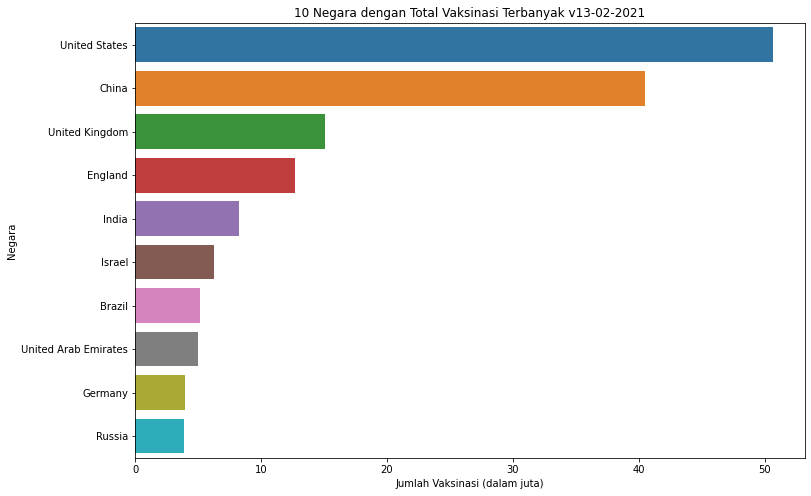

In [7]:
fig, ax = plt.subplots(figsize =(12,8))
sns.color_palette("hls", 8)
ax = sns.barplot(x=(total_vaccination_country.head(10).values)/1e6, y=total_vaccination_country.head(10).index)
ax.set_title("10 Negara dengan Total Vaksinasi Terbanyak v13-02-2021")
ax.set_ylabel("Negara")
ax.set_xlabel("Jumlah Vaksinasi (dalam juta)")
plt.show()

Jumlah Orang Tervaksin 

In [8]:
people_vaccinated_country = df.groupby('country').max().sort_values(by='people_vaccinated', ascending=False)[['people_vaccinated', 'people_fully_vaccinated']]
people_vaccinated_country.head()

,people_vaccinated,people_fully_vaccinated
country,,
United States,37056122.0,13082172.0
United Kingdom,14556827.0,534869.0
England,12246166.0,487699.0
Brazil,4946738.0,178468.0
Israel,3824480.0,2457430.0


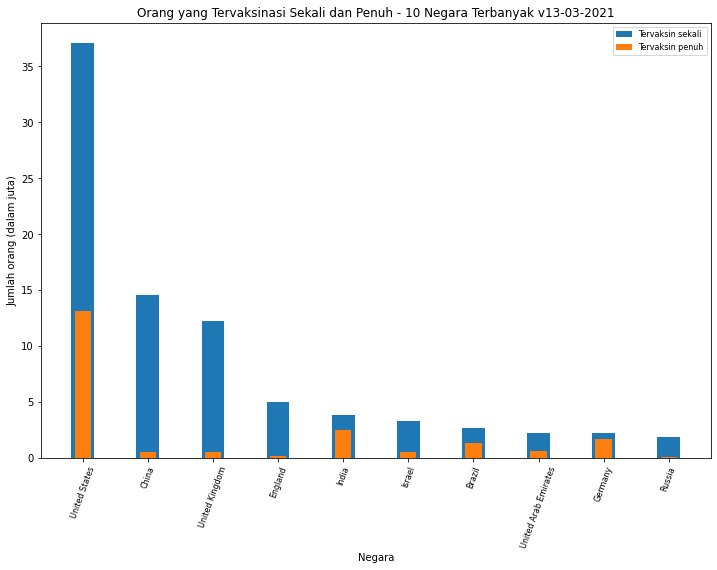

In [9]:
label = total_vaccination_country.head(10).index
people_vaccinated = people_vaccinated_country['people_vaccinated'].head(10)
people_fully = people_vaccinated_country['people_fully_vaccinated'].head(10)

x = np.arange(len(label))

fig, ax = plt.subplots(figsize=(12,8))
sns.color_palette("hls", 2)
ax.bar(label, people_vaccinated/1e6, width=0.35, label='Tervaksin sekali')
ax.bar(label, people_fully/1e6, width=0.25, label='Tervaksin penuh')

ax.set_title("Orang yang Tervaksinasi Sekali dan Penuh - 10 Negara Terbanyak v13-03-2021")
ax.set_xlabel('Negara')
ax.set_ylabel('Jumlah orang (dalam juta)')
ax.set_xticks(x)
ax.set_xticklabels(label, fontsize=8, rotation=70)

ax.legend(fontsize=8)
plt.show()

Jumlah yang tervaksin per seratus 

In [10]:
vaccinated_hundred = df.groupby('country').max().sort_values(by="total_vaccinations_per_hundred", ascending=False)[['total_vaccinations_per_hundred','people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred']]
vaccinated_hundred.head()

,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred
country,,,
Israel,72.58,44.19,28.39
Gibraltar,71.81,46.30,25.51
Seychelles,52.69,38.59,14.10
United Arab Emirates,50.61,8.46,2.53
Wales,23.90,23.77,0.13


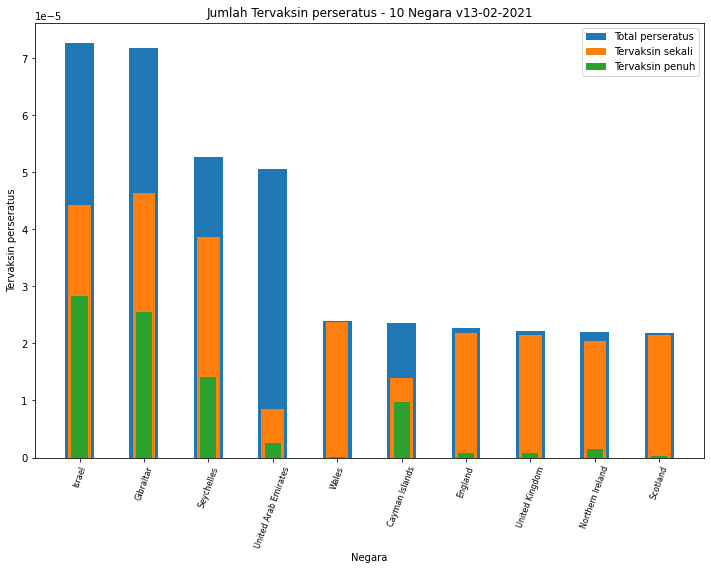

In [11]:
label = vaccinated_hundred.head(10).index
total_hundred = vaccinated_hundred['total_vaccinations_per_hundred'].head(10)
vaccinated = vaccinated_hundred['people_vaccinated_per_hundred'].head(10)
vaccinated_fully = vaccinated_hundred['people_fully_vaccinated_per_hundred'].head(10)
x = np.arange(len(label))

fig, ax = plt.subplots(figsize=(12,8))
ax.bar(label, total_hundred/1e6, width=0.45, label='Total perseratus')
ax.bar(label, vaccinated/1e6, width=0.35, label='Tervaksin sekali')
ax.bar(label, vaccinated_fully/1e6, width=0.25, label='Tervaksin penuh')
ax.set_title("Jumlah Tervaksin perseratus - 10 Negara v13-02-2021")
ax.set_ylabel('Tervaksin perseratus')
ax.set_xlabel('Negara')
ax.set_xticks(x)
ax.set_xticklabels(label, fontsize=8, rotation=70)

ax.legend()
plt.show()

In [57]:
vaccination_type = df.groupby('vaccines').sum().sort_values(by='total_vaccinations', ascending=False)
vaccination_type

,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
vaccines,,,,,,,,,
"Moderna, Pfizer/BioNTech",1.118616e+09,865306207.0,215742160.0,48063723.0,53312456.0,2480.90,1751.56,634.65,1019921.0
"Oxford/AstraZeneca, Pfizer/BioNTech",5.718647e+08,538022619.0,33834851.0,25015059.0,28254979.0,2389.16,2194.30,186.46,1292800.0
"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",3.268787e+08,257374887.0,61767212.0,17219312.0,17048554.0,1374.84,1036.60,257.40,779366.0
"Sinopharm/Beijing, Sinopharm/Wuhan, Sinovac",1.584870e+08,0.0,0.0,0.0,34922496.0,11.01,0.00,0.00,24255.0
"Covaxin, Oxford/AstraZeneca",1.064500e+08,0.0,0.0,8263858.0,7536062.0,7.71,0.00,0.00,5461.0
"Oxford/AstraZeneca, Pfizer/BioNTech, Sinopharm/Beijing, Sinopharm/Wuhan, Sputnik V",9.920366e+07,836568.0,250000.0,3641854.0,3950325.0,1003.04,8.46,2.53,399408.0
Sinovac,7.123842e+07,17564867.0,2939243.0,4923445.0,4952156.0,72.68,11.62,1.72,48453.0
"Oxford/AstraZeneca, Sinovac",5.725755e+07,56622057.0,500692.0,5125206.0,4209095.0,26.94,26.64,0.23,19803.0
Pfizer/BioNTech,3.900395e+07,31288752.0,3814240.0,1549993.0,2468639.0,1825.89,1479.98,293.08,1733386.0


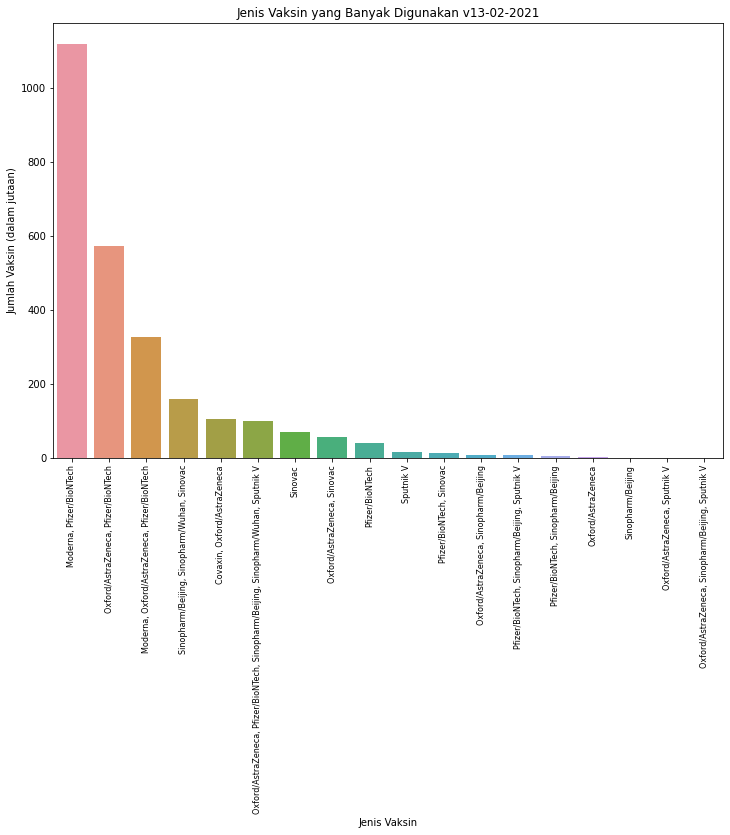

In [64]:
fig, ax = plt.subplots(figsize =(12,8))
sns.color_palette("hls", 8)
XX = np.arange(len(vaccination_type.index))
ax = sns.barplot(x=vaccination_type.index, y=(vaccination_type['total_vaccinations'])/1e6)
ax.set_title("Jenis Vaksin yang Banyak Digunakan v13-02-2021")
ax.set_ylabel("Jumlah Vaksin (dalam jutaan)")
ax.set_xlabel("Jenis Vaksin")
ax.set_xticks(XX)
ax.set_xticklabels(vaccination_type.index, fontsize=8, rotation = 90)
plt.show()

INDONESIA

In [16]:
total_indo = df[df['country']=='Indonesia'][['date','total_vaccinations']]
total_indo = total_indo.dropna()
total_indo.head()

,index,date,total_vaccinations
0,1331,2021-01-12,0.0
1,1341,2021-01-22,132000.0
2,1343,2021-01-24,149242.0
3,1344,2021-01-25,161959.0
4,1345,2021-01-26,245685.0


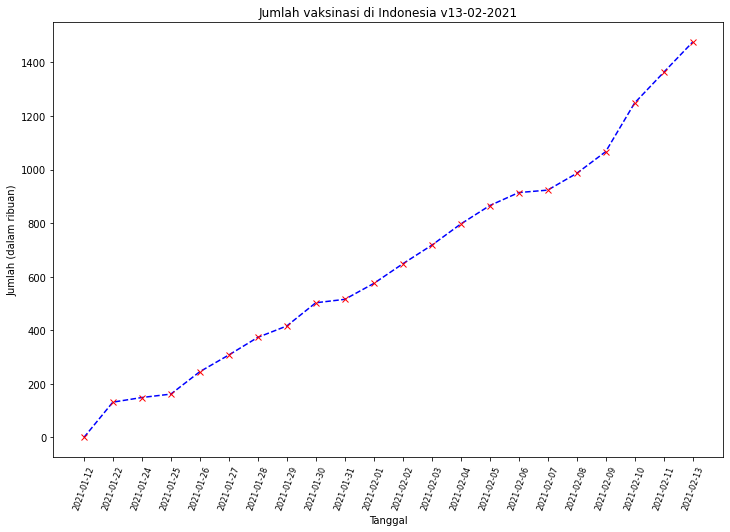

In [24]:
tgl = total_indo['date']
jumlah = total_indo['total_vaccinations']

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(tgl, jumlah/1000, marker = 'x', ls='--', color = 'b', mec='r')
ax.set_title("Jumlah vaksinasi di Indonesia | v13-02-2021")
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah (dalam ribuan)')
ax.set_xticks(tgl)
ax.set_xticklabels(tgl, fontsize=8, rotation=70)

plt.show()



In [27]:
vaccinated_indo = df[df['country']=='Indonesia'][['date','people_vaccinated', 'people_fully_vaccinated']]
vaccinated_indo = vaccinated_indo.dropna()
vaccinated_indo.tail()

,date,people_vaccinated,people_fully_vaccinated
1358,2021-02-08,814585.0,171270.0
1359,2021-02-09,845407.0,221453.0
1360,2021-02-10,969546.0,279251.0
1361,2021-02-11,1017186.0,345605.0
1363,2021-02-13,1060326.0,415486.0


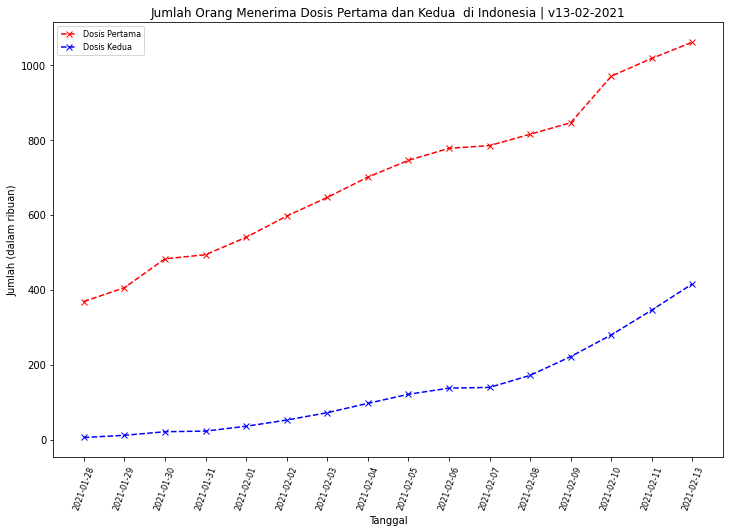

In [33]:
tgl_vaksin = vaccinated_indo['date']
jumlah_vaksin1 = vaccinated_indo['people_vaccinated']
jumlah_vaksin2 = vaccinated_indo['people_fully_vaccinated']

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(tgl_vaksin, jumlah_vaksin1/1000, marker = 'x', ls='--', color = 'r', mec='r', label='Dosis Pertama')
ax.plot(tgl_vaksin, jumlah_vaksin2/1000, marker = 'x', ls='--', color = 'b', mec='b', label='Dosis Kedua')
ax.set_title("Jumlah Orang Menerima Dosis Pertama dan Kedua  di Indonesia | v13-02-2021")
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah (dalam ribuan)')
ax.set_xticks(tgl_vaksin)
ax.set_xticklabels(tgl_vaksin, fontsize=8, rotation=70)
ax.legend(loc="upper left", fontsize=8)

plt.show()

In [41]:
indo_hundred = df[df['country']=='Indonesia'][['date', 'total_vaccinations_per_hundred','people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred']].dropna()
indo_hundred.head()

,date,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred
1347,2021-01-28,0.14,0.13,0.00
1348,2021-01-29,0.15,0.15,0.00
1349,2021-01-30,0.18,0.18,0.01
1350,2021-01-31,0.19,0.18,0.01
1351,2021-02-01,0.21,0.20,0.01


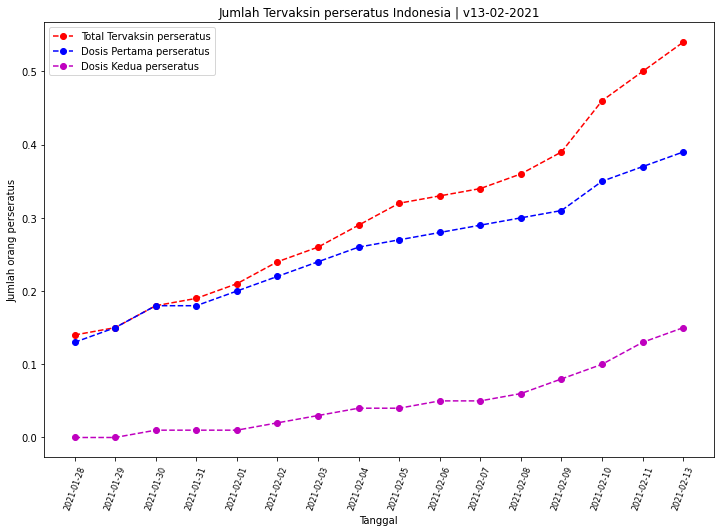

In [42]:
hun_tgl = indo_hundred['date']
tot_hun_indo = indo_hundred['total_vaccinations_per_hundred']
hun_indo = indo_hundred['people_vaccinated_per_hundred']
hunfull_indo = indo_hundred['people_fully_vaccinated_per_hundred']

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(hun_tgl, tot_hun_indo, marker = 'o', ls='--', color = 'r', mec='r', label='Total Tervaksin perseratus')
ax.plot(hun_tgl, hun_indo, marker = 'o', ls='--', color = 'b', mec='b', label='Dosis Pertama perseratus')
ax.plot(hun_tgl, hunfull_indo, marker = 'o', ls='--', color = 'm', mec='m', label='Dosis Kedua perseratus')
ax.set_title("Jumlah Tervaksin perseratus Indonesia | v13-02-2021")
ax.set_ylabel('Jumlah orang perseratus')
ax.set_xlabel('Tanggal')
ax.set_xticks(hun_tgl)
ax.set_xticklabels(hun_tgl, fontsize=8, rotation=70)

ax.legend()
plt.show()

In [45]:
daily = df[df['country']=='Indonesia'][['date', 'daily_vaccinations_per_million']]
daily = daily_indo.dropna()

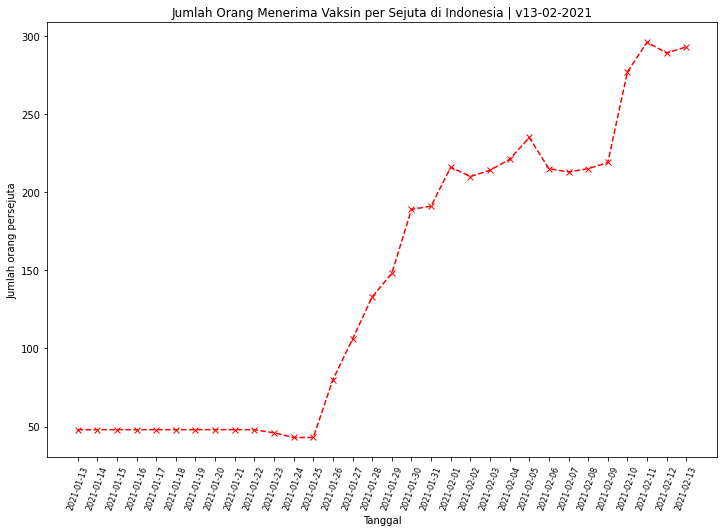

In [47]:
date = daily['date']
daily_indo = daily['daily_vaccinations_per_million']

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(date, daily_indo, marker = 'x', ls='--', color = 'r', mec='r')
ax.set_title("Jumlah Orang Menerima Vaksin per Sejuta di Indonesia | v13-02-2021")
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah orang persejuta')
ax.set_xticks(date)
ax.set_xticklabels(date, fontsize=8, rotation=70)

plt.show()